In [ ]:


### **Player Information:**
- **player** *(object)* → Name of the player.  
- **pos** *(object)* → Position of the player (e.g., PG, SG, SF, PF, C).  
- **age** *(int64)* → Age of the player during the season.  
- **bref_team_id** *(object)* → Basketball Reference team abbreviation (e.g., LAL for Los Angeles Lakers).  
- **season** *(object)* → Season year (e.g., "2022-23").  
- **season_end** *(int64)* → Year the season ended (e.g., 2023 for "2022-23" season).  

---

### **Games & Minutes Played:**
- **g** *(int64)* → Games played.  
- **gs** *(int64)* → Games started.  
- **mp** *(int64)* → Total minutes played.  

---

### **Shooting Statistics:**
- **fg** *(int64)* → Field goals made (successful shots).  
- **fga** *(int64)* → Field goals attempted (total shots taken).  
- **fg.** *(float64)* → Field goal percentage (`fg / fga`).  

- **x3p** *(int64)* → Three-point field goals made.  
- **x3pa** *(int64)* → Three-point field goals attempted.  
- **x3p.** *(float64)* → Three-point percentage (`x3p / x3pa`).  

- **x2p** *(int64)* → Two-point field goals made.  
- **x2pa** *(int64)* → Two-point field goals attempted.  
- **x2p.** *(float64)* → Two-point percentage (`x2p / x2pa`).  

- **efg.** *(float64)* → **Effective Field Goal Percentage (eFG%)**  
  - Adjusts for the fact that a 3-pointer is worth more than a 2-pointer.  
  - Formula: `(fg + 0.5 * x3p) / fga`.  

---

### **Free Throw Statistics:**
- **ft** *(int64)* → Free throws made.  
- **fta** *(int64)* → Free throws attempted.  
- **ft.** *(float64)* → Free throw percentage (`ft / fta`).  

---

### **Rebounding Stats:**
- **orb** *(int64)* → Offensive rebounds (rebounds on missed shots from teammates).  
- **drb** *(int64)* → Defensive rebounds (rebounds on missed shots from opponents).  
- **trb** *(int64)* → Total rebounds (`orb + drb`).  

---

### **Playmaking & Defense:**
- **ast** *(int64)* → Assists (passes leading to made shots).  
- **stl** *(int64)* → Steals (taking the ball from an opponent).  
- **blk** *(int64)* → Blocks (defensive stops on opponent’s shots).  

---

### **Turnovers & Fouls:**
- **tov** *(int64)* → Turnovers (losing possession).  
- **pf** *(int64)* → Personal fouls committed.  

---

### **Scoring:**
- **pts** *(int64)* → Total points scored (`(2 * x2p) + (3 * x3p) + ft`).  

---



In [237]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [239]:
df = pd.read_csv("../DataSets/NBA.csv")
df

,player,pos,age,bref_team_id,g,gs,mp,fg,fga,fg.,...,drb,trb,ast,stl,blk,tov,pf,pts,season,season_end
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,144,216,28,23,26,30,122,171,2013-2014,2013
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,190,332,43,40,57,71,203,265,2013-2014,2013
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,204,306,38,24,36,39,108,362,2013-2014,2013
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,230,262,248,35,3,146,136,1330,2013-2014,2013
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,183,277,40,23,46,63,187,328,2013-2014,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,159,228,217,78,16,204,151,939,2013-2014,2013
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,137,166,95,46,12,95,156,1144,2013-2014,2013
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,310,476,182,167,36,165,213,1417,2013-2014,2013
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,235,353,92,40,41,87,170,490,2013-2014,2013


In [241]:
df.dtypes

player           object
pos              object
age               int64
bref_team_id     object
g                 int64
gs                int64
mp                int64
fg                int64
fga               int64
fg.             float64
x3p               int64
x3pa              int64
x3p.            float64
x2p               int64
x2pa              int64
x2p.            float64
efg.            float64
ft                int64
fta               int64
ft.             float64
orb               int64
drb               int64
trb               int64
ast               int64
stl               int64
blk               int64
tov               int64
pf                int64
pts               int64
season           object
season_end        int64
dtype: object

In [243]:
df.isnull().sum()

player           0
pos              0
age              0
bref_team_id     0
g                0
gs               0
mp               0
fg               0
fga              0
fg.              2
x3p              0
x3pa             0
x3p.            67
x2p              0
x2pa             0
x2p.             3
efg.             2
ft               0
fta              0
ft.             20
orb              0
drb              0
trb              0
ast              0
stl              0
blk              0
tov              0
pf               0
pts              0
season           0
season_end       0
dtype: int64

In [245]:
df.rename(columns={
    "player": "Player Name",
    "pos": "Position",
    "age": "Age",
    "bref_team_id": "Team Abbreviation",
    "season": "Season",
    "season_end": "Season End Year",

    "g": "Games Played",
    "gs": "Games Started",
    "mp": "Total Minutes Played",

    "fg": "Field Goals Made",
    "fga": "Field Goals Attempted",
    "fg.": "Field Goal Percentage",

    "x3p": "Three-Point Field Goals Made",
    "x3pa": "Three-Point Field Goals Attempted",
    "x3p.": "Three-Point Percentage",

    "x2p": "Two-Point Field Goals Made",
    "x2pa": "Two-Point Field Goals Attempted",
    "x2p.": "Two-Point Percentage",

    "efg.": "Effective Field Goal Percentage",

    "ft": "Free Throws Made",
    "fta": "Free Throws Attempted",
    "ft.": "Free Throw Percentage",

    "orb": "Offensive Rebounds",
    "drb": "Defensive Rebounds",
    "trb": "Total Rebounds",

    "ast": "Assists",
    "stl": "Steals",
    "blk": "Blocks",

    "tov": "Turnovers",
    "pf": "Personal Fouls",

    "pts": "Total Points Scored"
}, inplace=True)


In [437]:
df.columns = df.columns.str.replace(' ,-', '_')

In [439]:
df.dtypes

Player_Name                           object
Position                              object
Age                                    int64
Team_Abbreviation                     object
Games_Played                           int64
Games_Started                          int64
Total_Minutes_Played                   int64
Field_Goals_Made                       int64
Field_Goals_Attempted                  int64
Field_Goal_Percentage                float64
Three-Point_Field_Goals_Made           int64
Three-Point_Field_Goals_Attempted      int64
Three-Point_Percentage               float64
Two-Point_Field_Goals_Made             int64
Two-Point_Field_Goals_Attempted        int64
Two-Point_Percentage                 float64
Effective_Field_Goal_Percentage      float64
Free_Throws_Made                       int64
Free_Throws_Attempted                  int64
Free_Throw_Percentage                float64
Offensive_Rebounds                     int64
Defensive_Rebounds                     int64
Total_Rebo

In [289]:
df["Field_Goal_Percentage"] = df["Field_Goal_Percentage"].fillna(0)
df["Three-Point_Percentage"]= df["Three-Point_Percentage"].fillna(0)

In [291]:
df.isnull().sum()

Player_Name                          0
Position                             0
Age                                  0
Team_Abbreviation                    0
Games_Played                         0
Games_Started                        0
Total_Minutes_Played                 0
Field_Goals_Made                     0
Field_Goals_Attempted                0
Field_Goal_Percentage                0
Three-Point_Field_Goals_Made         0
Three-Point_Field_Goals_Attempted    0
Three-Point_Percentage               0
Two-Point_Field_Goals_Made           0
Two-Point_Field_Goals_Attempted      0
Two-Point_Percentage                 0
Effective_Field_Goal_Percentage      0
Free_Throws_Made                     0
Free_Throws_Attempted                0
Free_Throw_Percentage                0
Offensive_Rebounds                   0
Defensive_Rebounds                   0
Total_Rebounds                       0
Assists                              0
Steals                               0
Blocks                   

In [297]:
df["Two-Point_Percentage"] = df["Two-Point_Percentage"].fillna(0)

In [299]:
df["Effective_Field_Goal_Percentage"] = df["Effective_Field_Goal_Percentage"].fillna(0)

In [301]:
df["Free_Throw_Percentage"] = df["Free_Throw_Percentage"].fillna(0)

In [303]:
df.isnull().sum()

Player_Name                          0
Position                             0
Age                                  0
Team_Abbreviation                    0
Games_Played                         0
Games_Started                        0
Total_Minutes_Played                 0
Field_Goals_Made                     0
Field_Goals_Attempted                0
Field_Goal_Percentage                0
Three-Point_Field_Goals_Made         0
Three-Point_Field_Goals_Attempted    0
Three-Point_Percentage               0
Two-Point_Field_Goals_Made           0
Two-Point_Field_Goals_Attempted      0
Two-Point_Percentage                 0
Effective_Field_Goal_Percentage      0
Free_Throws_Made                     0
Free_Throws_Attempted                0
Free_Throw_Percentage                0
Offensive_Rebounds                   0
Defensive_Rebounds                   0
Total_Rebounds                       0
Assists                              0
Steals                               0
Blocks                   

In [305]:
df["Team_Abbreviation"].unique()

array(['TOT', 'OKC', 'ORL', 'NOP', 'NYK', 'POR', 'MIA', 'MEM', 'BRK',
       'PHI', 'MIL', 'ATL', 'WAS', 'GSW', 'DEN', 'HOU', 'SAS', 'BOS',
       'PHO', 'MIN', 'LAC', 'CLE', 'UTA', 'DET', 'CHA', 'DAL', 'CHI',
       'LAL', 'IND', 'TOR', 'SAC'], dtype=object)

In [311]:
df["Position"].unique()

array(['SF', 'C', 'PF', 'SG', 'PG', 'G', 'F'], dtype=object)

In [317]:
df["Position"] = df["Position"].rename({"SF":"Small_Forward","C":"Center","PF":"Power_Forward","SG":"Shooting_Guard"
                                       ,"PG":"Point_Guard","G":"Guard","F":"Forward"})

In [319]:
df

,Player_Name,Position,Age,Team_Abbreviation,Games_Played,Games_Started,Total_Minutes_Played,Field_Goals_Made,Field_Goals_Attempted,Field_Goal_Percentage,...,Defensive_Rebounds,Total_Rebounds,Assists,Steals,Blocks,Turnovers,Personal_Fouls,Total_Points_Scored,Season,Season_End_Year
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,144,216,28,23,26,30,122,171,2013-2014,2013
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,190,332,43,40,57,71,203,265,2013-2014,2013
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,204,306,38,24,36,39,108,362,2013-2014,2013
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,230,262,248,35,3,146,136,1330,2013-2014,2013
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,183,277,40,23,46,63,187,328,2013-2014,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,159,228,217,78,16,204,151,939,2013-2014,2013
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,137,166,95,46,12,95,156,1144,2013-2014,2013
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,310,476,182,167,36,165,213,1417,2013-2014,2013
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,235,353,92,40,41,87,170,490,2013-2014,2013


In [341]:
df["Points_per_game"] = df["Total_Points_Scored"]/df["Games_Played"]

In [343]:
df["Field_goal_efficiency"] = df["Field_Goals_Made"]/df["Field_Goals_Attempted"]

In [345]:
df["Aisst_to_turnover"] = df["Assists"]/df["Turnovers"]

In [347]:
df["Rebound_efficiency"] = df["Total_Rebounds"]/df["Total_Minutes_Played"]

In [349]:
df.head()

,Player_Name,Position,Age,Team_Abbreviation,Games_Played,Games_Started,Total_Minutes_Played,Field_Goals_Made,Field_Goals_Attempted,Field_Goal_Percentage,...,Blocks,Turnovers,Personal_Fouls,Total_Points_Scored,Season,Season_End_Year,Points_per_game,Field_goal_efficiency,Aisst_to_turnover,Rebound_efficiency
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,26,30,122,171,2013-2014,2013,2.714286,0.468085,0.933333,0.255018
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,57,71,203,265,2013-2014,2013,3.271605,0.502703,0.605634,0.277360
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,36,39,108,362,2013-2014,2013,6.830189,0.520000,0.974359,0.318418
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,3,146,136,1330,2013-2014,2013,18.219178,0.458952,1.698630,0.102665
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,46,63,187,328,2013-2014,2013,5.857143,0.546185,0.634921,0.291272


In [351]:
df.tail()

,Player_Name,Position,Age,Team_Abbreviation,Games_Played,Games_Started,Total_Minutes_Played,Field_Goals_Made,Field_Goals_Attempted,Field_Goal_Percentage,...,Blocks,Turnovers,Personal_Fouls,Total_Points_Scored,Season,Season_End_Year,Points_per_game,Field_goal_efficiency,Aisst_to_turnover,Rebound_efficiency
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,16,204,151,939,2013-2014,2013,13.041667,0.426980,1.063725,0.129178
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,12,95,156,1144,2013-2014,2013,17.875000,0.435321,1.000000,0.091713
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,36,165,213,1417,2013-2014,2013,17.936709,0.453624,1.103030,0.175129
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,41,87,170,490,2013-2014,2013,5.975610,0.425743,1.057471,0.249294
480,Tyler Zeller,C,24,CLE,70,9,1049,156,290,0.538,...,38,60,137,399,2013-2014,2013,5.700000,0.537931,0.600000,0.268827


In [353]:
df.describe()

,Age,Games_Played,Games_Started,Total_Minutes_Played,Field_Goals_Made,Field_Goals_Attempted,Field_Goal_Percentage,Three-Point_Field_Goals_Made,Three-Point_Field_Goals_Attempted,Three-Point_Percentage,...,Steals,Blocks,Turnovers,Personal_Fouls,Total_Points_Scored,Season_End_Year,Points_per_game,Field_goal_efficiency,Aisst_to_turnover,Rebound_efficiency
count,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,...,481.000000,481.000000,481.000000,481.000000,481.000000,481.0,481.000000,479.000000,472.000000,481.000000
mean,26.509356,53.253638,25.571726,1237.386694,192.881497,424.463617,0.434622,39.613306,110.130977,0.245397,...,39.280665,24.103950,71.862786,105.869023,516.582121,2013.0,8.102632,0.436420,inf,0.179435
std,4.198265,25.322711,29.658465,897.258840,171.832793,368.850833,0.102401,50.855639,132.751732,0.176482,...,34.783590,30.875381,62.701690,71.213627,470.422228,0.0,5.857587,0.098677,NaN,0.099541
min,19.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2013.0,0.000000,0.000000,0.000000,0.000000
25%,23.000000,32.000000,0.000000,388.000000,47.000000,110.000000,0.400000,0.000000,3.000000,0.000000,...,9.000000,4.000000,21.000000,44.000000,115.000000,2013.0,3.483871,0.400516,0.853860,0.104675
50%,26.000000,61.000000,10.000000,1141.000000,146.000000,332.000000,0.437000,16.000000,48.000000,0.314607,...,32.000000,14.000000,58.000000,104.000000,401.000000,2013.0,6.689189,0.437500,1.272818,0.161381
75%,29.000000,76.000000,54.000000,2016.000000,307.000000,672.000000,0.479000,68.000000,193.000000,0.366460,...,60.000000,32.000000,108.000000,158.000000,821.000000,2013.0,11.666667,0.479763,1.901101,0.237346
max,39.000000,83.000000,82.000000,3122.000000,849.000000,1688.000000,1.000000,261.000000,615.000000,1.000000,...,191.000000,219.000000,295.000000,273.000000,2593.000000,2013.0,32.012346,1.000000,inf,1.000000


In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Player_Name                        481 non-null    object 
 1   Position                           481 non-null    object 
 2   Age                                481 non-null    int64  
 3   Team_Abbreviation                  481 non-null    object 
 4   Games_Played                       481 non-null    int64  
 5   Games_Started                      481 non-null    int64  
 6   Total_Minutes_Played               481 non-null    int64  
 7   Field_Goals_Made                   481 non-null    int64  
 8   Field_Goals_Attempted              481 non-null    int64  
 9   Field_Goal_Percentage              481 non-null    float64
 10  Three-Point_Field_Goals_Made       481 non-null    int64  
 11  Three-Point_Field_Goals_Attempted  481 non-null    int64  

In [357]:
df.corr(numeric_only = True)

,Age,Games_Played,Games_Started,Total_Minutes_Played,Field_Goals_Made,Field_Goals_Attempted,Field_Goal_Percentage,Three-Point_Field_Goals_Made,Three-Point_Field_Goals_Attempted,Three-Point_Percentage,...,Steals,Blocks,Turnovers,Personal_Fouls,Total_Points_Scored,Season_End_Year,Points_per_game,Field_goal_efficiency,Aisst_to_turnover,Rebound_efficiency
Age,1.000000,-0.012074,0.025163,0.007961,-0.009749,-0.018304,0.017929,0.050611,0.028850,0.012090,...,-0.028315,-0.017398,-0.030789,-0.028221,-0.011910,NaN,0.010567,0.025196,0.179108,-0.047022
Games_Played,-0.012074,1.000000,0.610951,0.864487,0.739993,0.746963,0.342499,0.518074,0.537011,0.243597,...,0.709650,0.475581,0.713508,0.865797,0.728462,NaN,0.574831,0.322200,0.169877,-0.010995
Games_Started,0.025163,0.610951,1.000000,0.860036,0.821619,0.811531,0.240620,0.501808,0.515718,0.162971,...,0.743178,0.505589,0.767107,0.725573,0.810294,NaN,0.756825,0.234584,0.180038,0.048114
Total_Minutes_Played,0.007961,0.864487,0.860036,1.000000,0.931120,0.936883,0.286372,0.645056,0.666126,0.276297,...,0.852331,0.506254,0.885406,0.884484,0.927464,NaN,0.829131,0.273686,0.235923,-0.038177
Field_Goals_Made,-0.009749,0.739993,0.821619,0.931120,1.000000,0.988262,0.286553,0.597239,0.613988,0.239951,...,0.786597,0.484208,0.903383,0.798769,0.992041,NaN,0.931558,0.278136,0.153582,0.011795
Field_Goals_Attempted,-0.018304,0.746963,0.811531,0.936883,0.988262,1.000000,0.222932,0.662004,0.685535,0.289914,...,0.803290,0.412738,0.910689,0.786560,0.989211,NaN,0.926751,0.211289,0.206942,-0.055133
Field_Goal_Percentage,0.017929,0.342499,0.240620,0.286372,0.286553,0.222932,1.000000,-0.010666,-0.025327,-0.082476,...,0.197596,0.399377,0.232955,0.370017,0.257634,NaN,0.284043,0.999996,-0.318771,0.399721
Three-Point_Field_Goals_Made,0.050611,0.518074,0.501808,0.645056,0.597239,0.662004,-0.010666,1.000000,0.991700,0.539664,...,0.592092,-0.043707,0.560520,0.446711,0.655342,NaN,0.596556,-0.025488,0.369223,-0.362452
Three-Point_Field_Goals_Attempted,0.028850,0.537011,0.515718,0.666126,0.613988,0.685535,-0.025327,0.991700,1.000000,0.538397,...,0.622973,-0.040987,0.589799,0.463455,0.672076,NaN,0.612280,-0.041680,0.378711,-0.372429
Three-Point_Percentage,0.012090,0.243597,0.162971,0.276297,0.239951,0.289914,-0.082476,0.539664,0.538397,1.000000,...,0.288919,-0.147881,0.230831,0.105314,0.272773,NaN,0.282378,-0.111971,0.382758,-0.455956


C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\3619661376.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.Team_Abbreviation, y=df.Total_Minutes_Played, estimator=np.mean,palette="coolwarm")


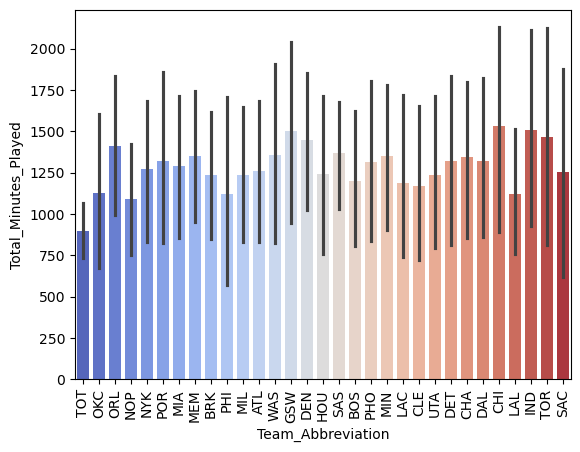

In [383]:
sns.barplot(x=df.Team_Abbreviation, y=df.Total_Minutes_Played, estimator=np.mean,palette="coolwarm")
plt.xticks(rotation=90)
plt.show()


In [385]:
print(df["Total_Minutes_Played"].describe())


count     481.000000
mean     1237.386694
std       897.258840
min         1.000000
25%       388.000000
50%      1141.000000
75%      2016.000000
max      3122.000000
Name: Total_Minutes_Played, dtype: float64


C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\3586399731.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df.Team_Abbreviation, y=df.Total_Minutes_Played,palette="coolwarm")


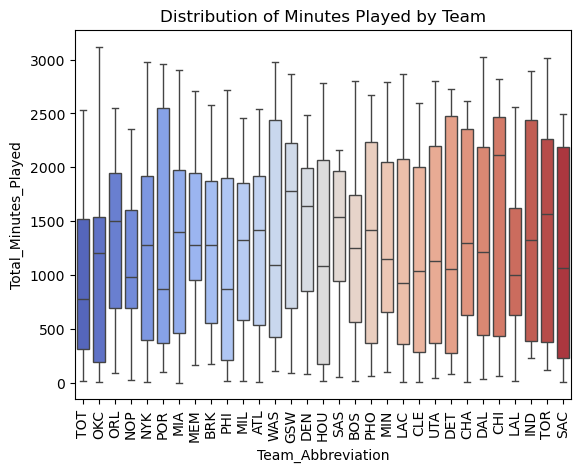

In [391]:
sns.boxplot(x=df.Team_Abbreviation, y=df.Total_Minutes_Played,palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Distribution of Minutes Played by Team")
plt.show()


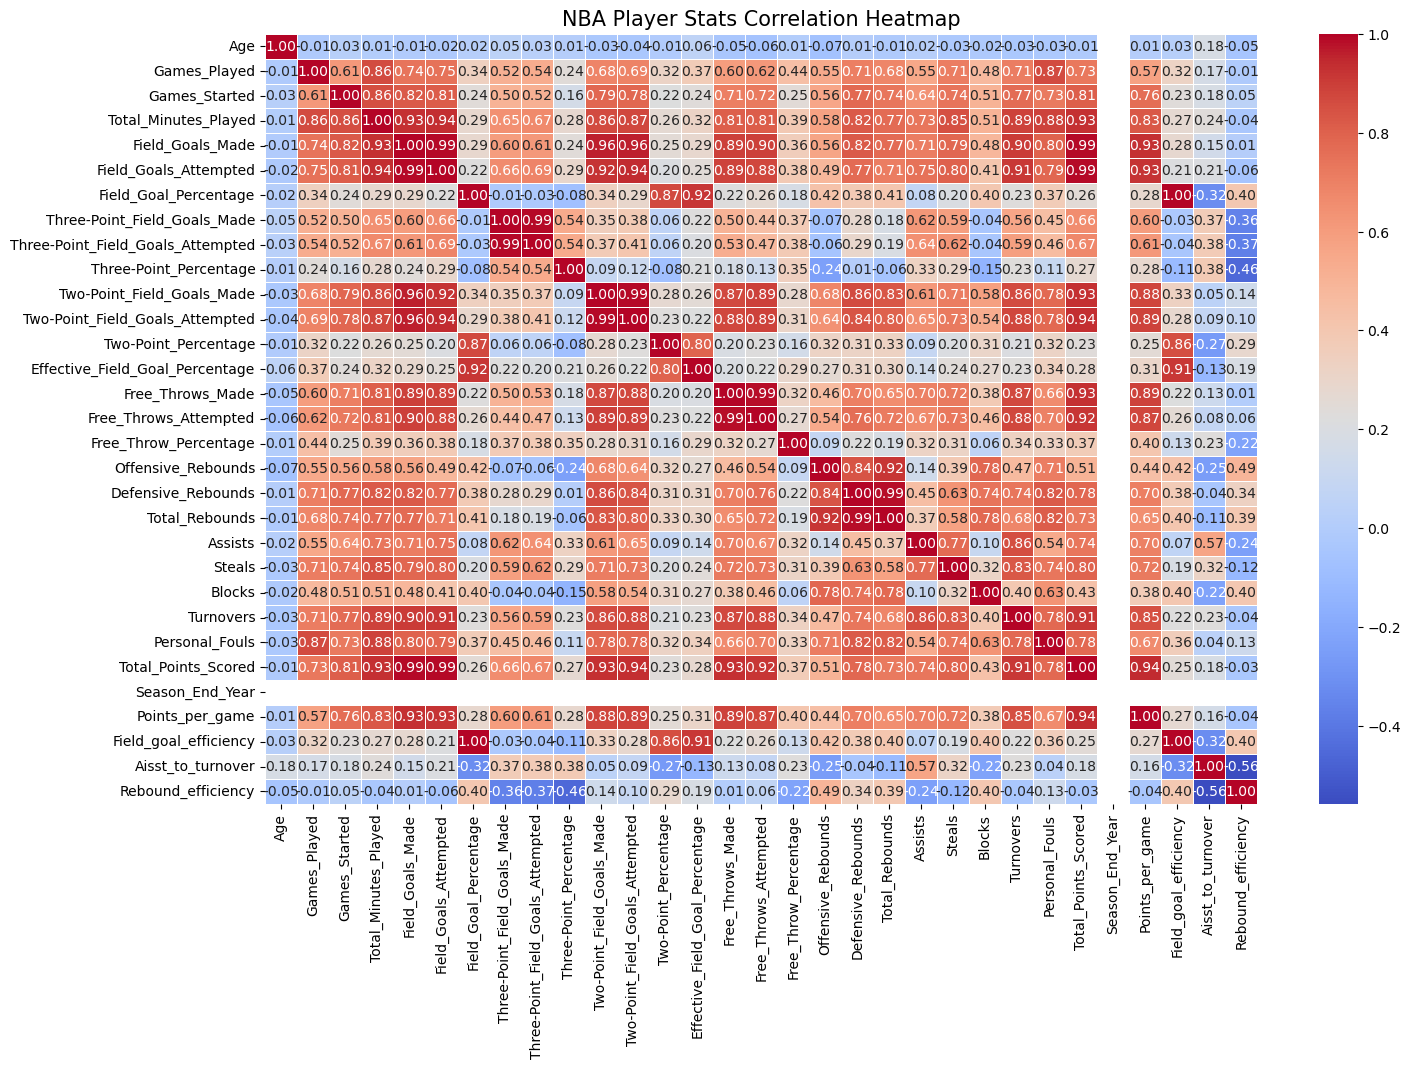

In [365]:
corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize=(16,10)) 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("NBA Player Stats Correlation Heatmap", fontsize=15)
plt.show()

## Player Analysis

# 1)Who are the top 10 players by total points (pts)?

In [369]:
top_10_players = df[['Player_Name', 'Total_Points_Scored']].sort_values(by='Total_Points_Scored', ascending=False).head(10)
print(top_10_players)


         Player_Name  Total_Points_Scored
133     Kevin Durant                 2593
17   Carmelo Anthony                 2112
225     LeBron James                 2089
277       Kevin Love                 2010
179    Blake Griffin                 1930
110    Stephen Curry                 1873
185     James Harden                 1851
123    DeMar DeRozan                 1791
162      Paul George                 1737
332    Dirk Nowitzki                 1735


C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\1053811536.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Points_Scored', y='Player_Name', data=top_10_players, palette='coolwarm')


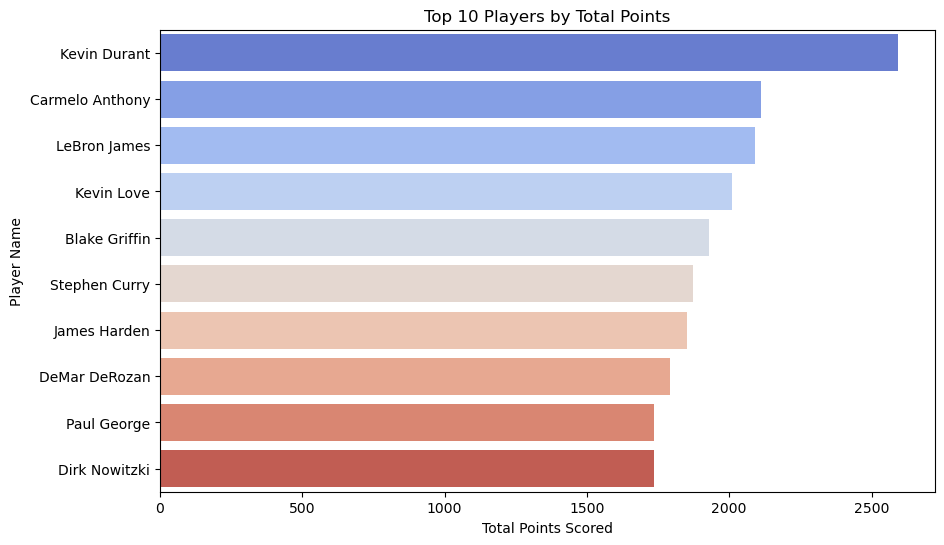

In [371]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Points_Scored', y='Player_Name', data=top_10_players, palette='coolwarm')
plt.xlabel('Total Points Scored')
plt.ylabel('Player Name')
plt.title('Top 10 Players by Total Points')
plt.show()

## 2) Which players have the highest three-point percentage (x3p.)?

In [374]:
top_3p_shooters = df[['Player_Name', 'Three-point_percentage']].sort_values(by='Three-point_percentage', ascending=False).head(10)
print(top_3p_shooters)


KeyError: "['Three-point_percentage'] not in index"

C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\685716499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Three-point_percentage', y='Player_Name', data=top_3p_shooters, palette='coolwarm')


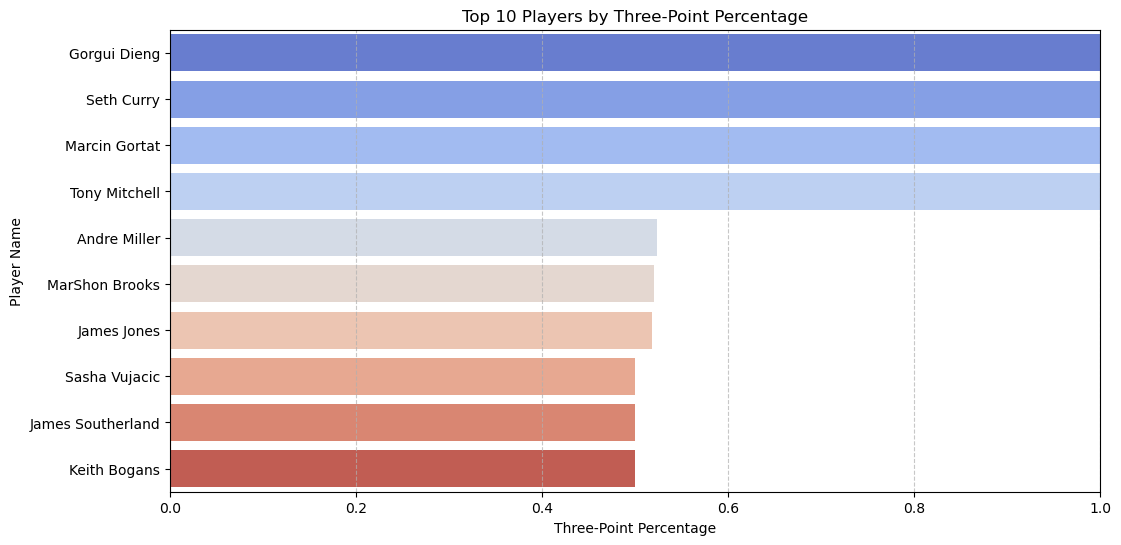

In [376]:

plt.figure(figsize=(12, 6))
sns.barplot(x='Three-point_percentage', y='Player_Name', data=top_3p_shooters, palette='coolwarm')
plt.xlabel('Three-Point Percentage')
plt.ylabel('Player Name')
plt.title('Top 10 Players by Three-Point Percentage')
plt.xlim(0, 1)  
plt.grid(axis='x', linestyle='--', alpha=0.7)  

plt.show()

## What are the average stats (points, assists, rebounds) by position (pos)?

In [381]:
avg_stats_by_pos = df.groupby('Position')[['Total_Points_Scored', 'Assists', 'Total_Rebounds']].mean().reset_index()
avg_stats_by_pos


,Position,Total_Points_Scored,Assists,Total_Rebounds
0,C,425.066667,55.044444,313.177778
1,F,4.000000,0.000000,5.000000
2,G,6.000000,3.000000,12.000000
3,PF,571.031250,78.718750,315.020833
4,PG,611.141176,247.717647,148.211765
5,SF,493.989899,91.505051,204.484848
6,SG,500.357798,105.513761,127.275229


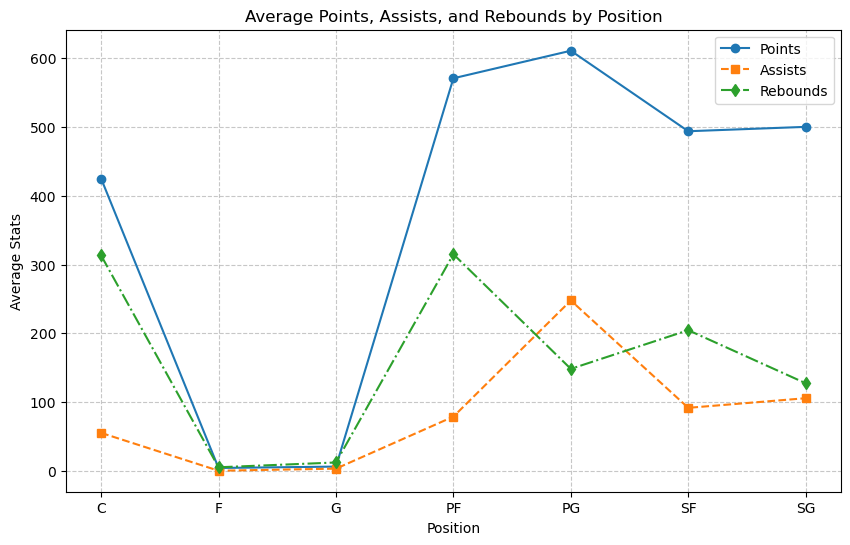

In [395]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(avg_stats_by_pos['Position'], avg_stats_by_pos['Total_Points_Scored'], marker='o', label='Points', linestyle='-')
plt.plot(avg_stats_by_pos['Position'], avg_stats_by_pos['Assists'], marker='s', label='Assists', linestyle='--')
plt.plot(avg_stats_by_pos['Position'], avg_stats_by_pos['Total_Rebounds'], marker='d', label='Rebounds', linestyle='-.')

# Labels and Title
plt.xlabel('Position')
plt.ylabel('Average Stats')
plt.title('Average Points, Assists, and Rebounds by Position')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

## How does player age correlate with performance metrics like pts, trb, and ast

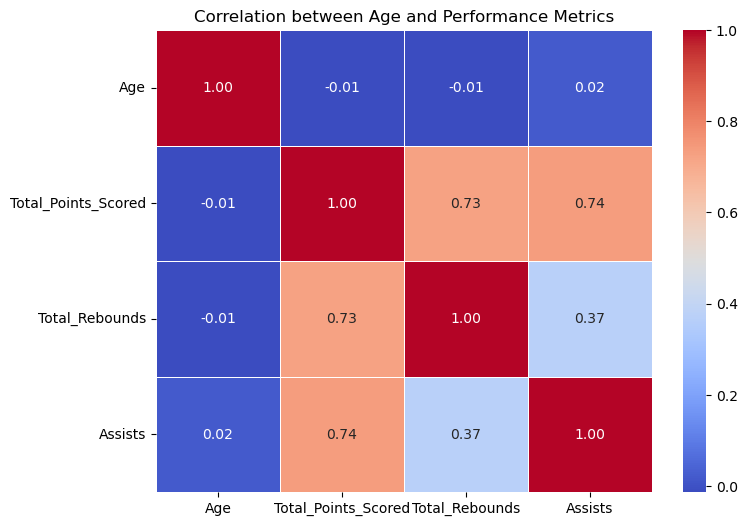

In [404]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns for correlation
correlation_data = df[['Age', 'Total_Points_Scored', 'Total_Rebounds', 'Assists']]

# Compute correlation matrix
corr_matrix = correlation_data.corr()

# 📌 Heatmap for correlation
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation between Age and Performance Metrics")
plt.show()




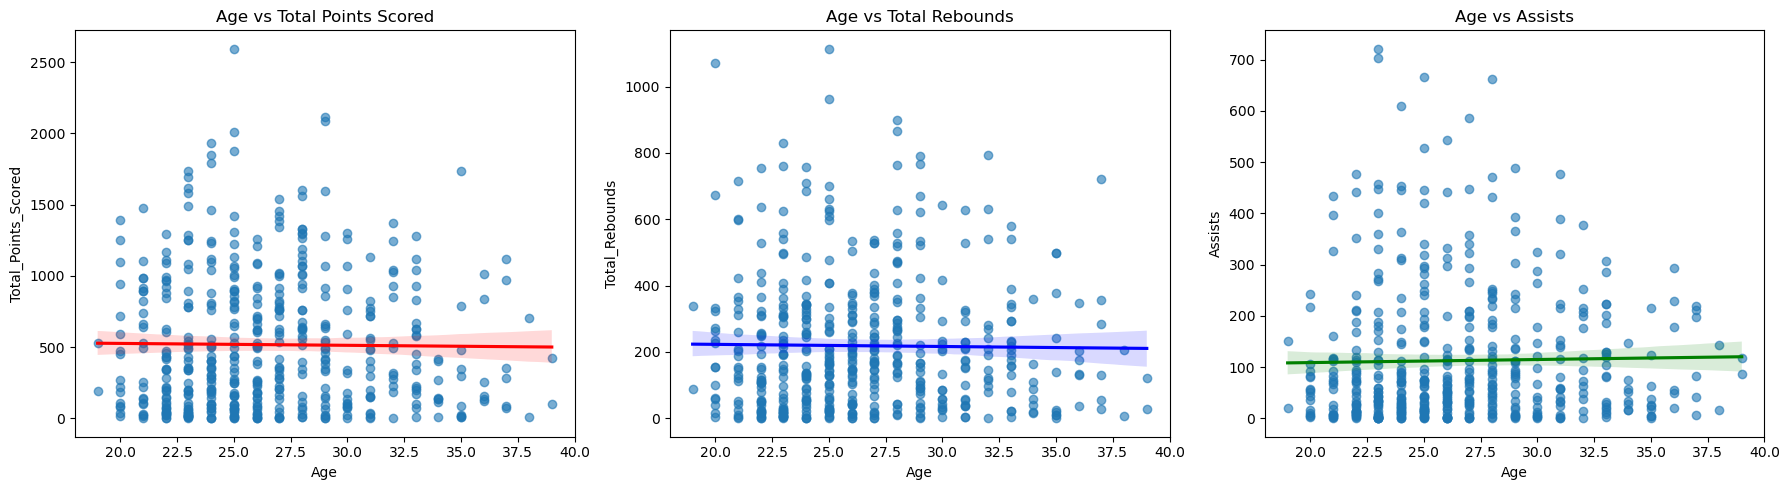

In [408]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Total Points
sns.regplot(x=df['Age'], y=df['Total_Points_Scored'], ax=axes[0], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('Age vs Total Points Scored')

# Age vs Total Rebounds
sns.regplot(x=df['Age'], y=df['Total_Rebounds'], ax=axes[1], scatter_kws={'alpha':0.6}, line_kws={'color':'blue'})
axes[1].set_title('Age vs Total Rebounds')

# Age vs Assists
sns.regplot(x=df['Age'], y=df['Assists'], ax=axes[2], scatter_kws={'alpha':0.6}, line_kws={'color':'green'})
axes[2].set_title('Age vs Assists')

plt.tight_layout()
plt.show()

## Team Analysis

## Which team scored the most total points (pts)?

In [416]:
team_points = df.groupby("Team_Abbreviation")["Total_Points_Scored"].sum().reset_index()
top_team = team_points.sort_values(by="Total_Points_Scored", ascending=False).head(10)
top_team

,Team_Abbreviation,Total_Points_Scored
28,TOT,21502
24,POR,8753
23,PHO,8629
6,DAL,8597
12,LAC,8582
17,MIN,8528
20,OKC,8492
26,SAS,8437
10,HOU,8385
8,DET,8286


## What is the average field goal percentage (fg.) by team?

In [424]:
team_fg = df.groupby("Team_Abbreviation")["Field_Goal_Percentage"].mean().reset_index()

# Sort in descending order
team_fg = team_fg.sort_values(by="Field_Goal_Percentage", ascending=False).head(10)
team_fg

,Team_Abbreviation,Field_Goal_Percentage
15,MIA,0.517667
26,SAS,0.468786
10,HOU,0.464267
14,MEM,0.462769
2,BRK,0.462133
6,DAL,0.459067
23,PHO,0.456733
16,MIL,0.456231
29,UTA,0.454250
11,IND,0.450583


## Which team has the highest rebound efficiency (total trb / total mp)?

In [443]:

df["Rebound_efficiency"] = df["Total_Rebounds"] / df["Total_Minutes_Played"]
team_rebound_eff = df.groupby("Team_Abbreviation")["Rebound_efficiency"].mean().reset_index()


team_rebound_eff = team_rebound_eff.sort_values(by="Rebound_efficiency", ascending=False).head(10)
team_rebound_eff

,Team_Abbreviation,Rebound_efficiency
0,ATL,0.234037
9,GSW,0.230389
15,MIA,0.213321
16,MIL,0.196796
7,DEN,0.194735
24,POR,0.193269
23,PHO,0.191654
26,SAS,0.191255
10,HOU,0.190685
17,MIN,0.188056


## Compare team performances for two-point shots (x2p) vs. three-point shots (x3p).

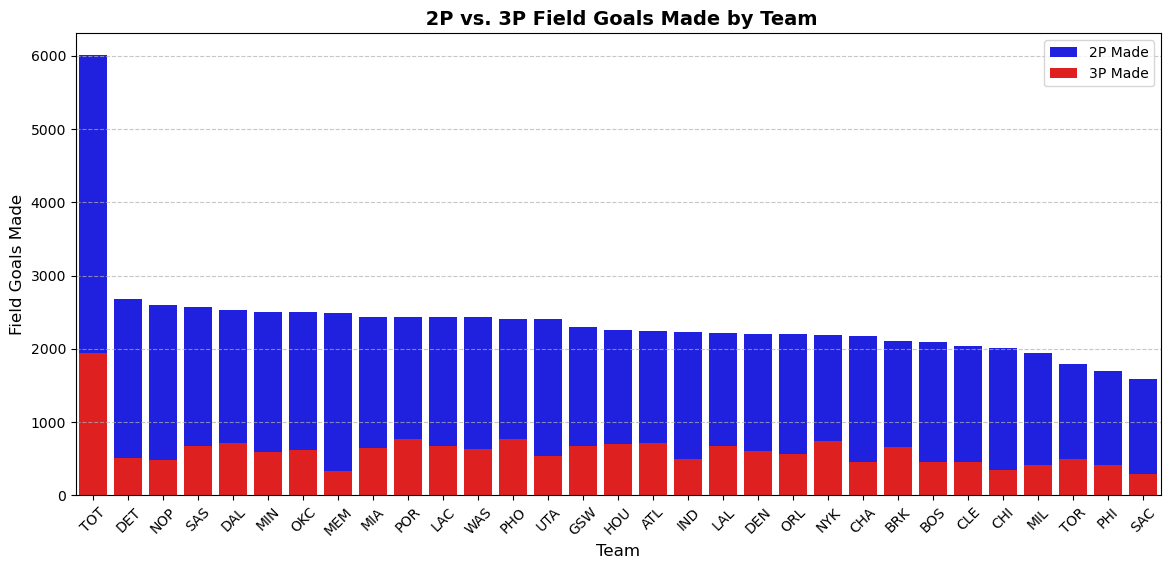

In [450]:
# Group by Team and sum 2P and 3P
team_shots = df.groupby("Team_Abbreviation")[["Two-Point_Field_Goals_Made", "Three-Point_Field_Goals_Made"]].sum().reset_index()

# Bar Chart for 2P vs. 3P by team
plt.figure(figsize=(14, 6))
team_shots = team_shots.sort_values(by="Two-Point_Field_Goals_Made", ascending=False)

sns.barplot(data=team_shots, x="Team_Abbreviation", y="Two-Point_Field_Goals_Made", color="blue", label="2P Made")
sns.barplot(data=team_shots, x="Team_Abbreviation", y="Three-Point_Field_Goals_Made", color="red", label="3P Made")

plt.title(" 2P vs. 3P Field Goals Made by Team", fontsize=14, fontweight='bold')
plt.xlabel("Team", fontsize=12)
plt.ylabel("Field Goals Made", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Seasonal Trends

## How do average points, rebounds, and assists vary across seasons?

In [458]:

seasonal_stats = df.groupby("Season")[["Total_Points_Scored", "Total_Rebounds", "Assists"]].mean().reset_index()
seasonal_stats


,Season,Total_Points_Scored,Total_Rebounds,Assists
0,2013-2014,516.582121,218.627859,112.536383


## Are younger or older players performing better in recent seasons?

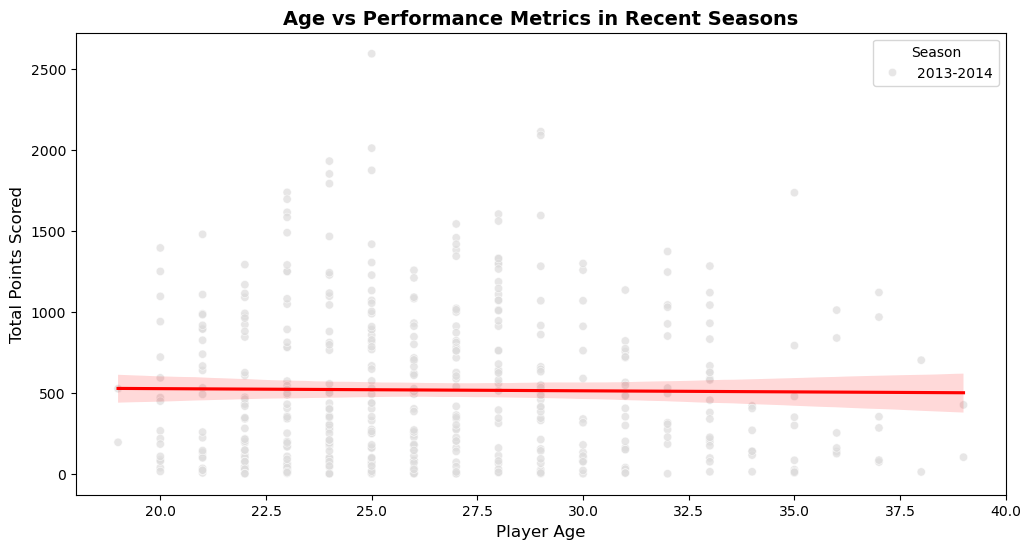

In [475]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 6))

# Scatter plot with regression line for Age vs Total Points Scored
sns.scatterplot(x=df["Age"], y=df["Total_Points_Scored"], hue=df["Season"], palette="coolwarm", alpha=0.7)
sns.regplot(x=df["Age"], y=df["Total_Points_Scored"], scatter=False, color='red')

# Labels and title
plt.xlabel("Player Age", fontsize=12)
plt.ylabel("Total Points Scored", fontsize=12)
plt.title("Age vs Performance Metrics in Recent Seasons", fontsize=14, fontweight='bold')
plt.legend(title="Season", bbox_to_anchor=(1, 1))

# Show the plot
plt.show()


## Shooting & Efficiency



## What is the shooting efficiency (efg.) distribution for players across positions?


C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\572550023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Position'], y=df['Effective_Field_Goal_Percentage'], palette="coolwarm")


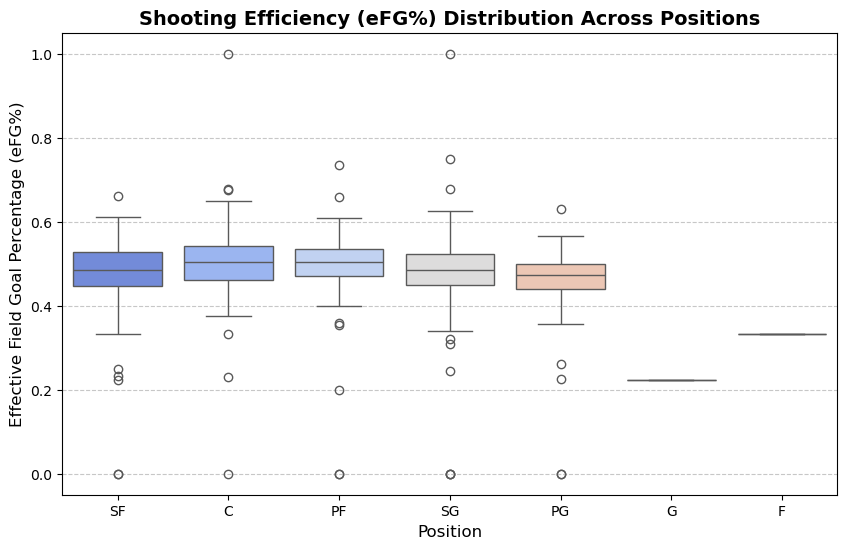

In [486]:


plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Position'], y=df['Effective_Field_Goal_Percentage'], palette="coolwarm")

# Labels and Title
plt.xlabel("Position", fontsize=12)
plt.ylabel("Effective Field Goal Percentage (eFG%)", fontsize=12)
plt.title("Shooting Efficiency (eFG%) Distribution Across Positions", fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



## How do free throw percentages (ft.) compare across teams?

C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\3094399213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Team_Abbreviation'], y=df['Free_Throw_Percentage'], palette="coolwarm")


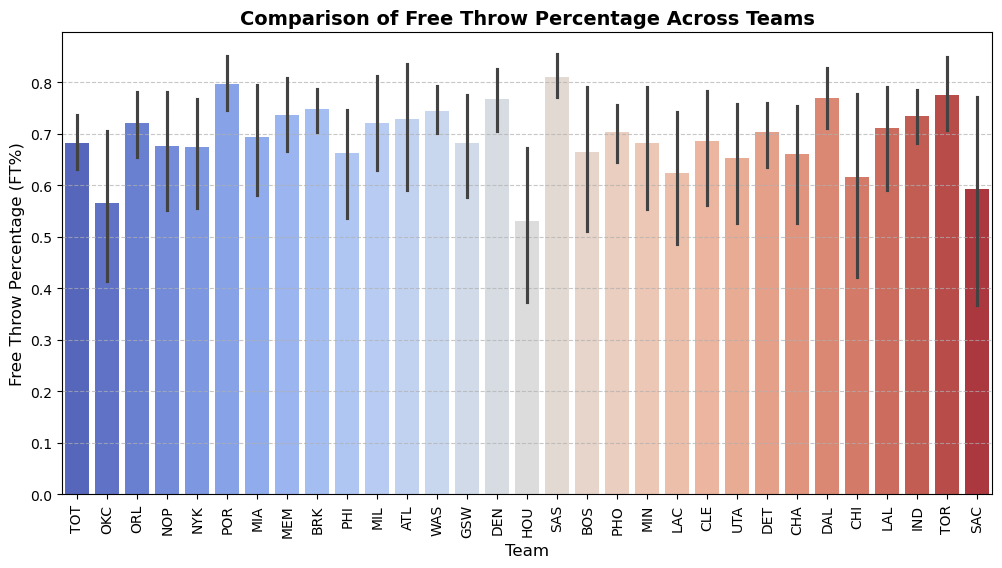

In [489]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['Team_Abbreviation'], y=df['Free_Throw_Percentage'], palette="coolwarm")

# Labels and Title
plt.xticks(rotation=90)
plt.xlabel("Team", fontsize=12)
plt.ylabel("Free Throw Percentage (FT%)", fontsize=12)
plt.title("Comparison of Free Throw Percentage Across Teams", fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


##  Top 10 players by total points.

C:\Users\RAHUL\AppData\Local\Temp\ipykernel_38824\1195957717.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Points_Scored', y='Player_Name', data=top_players, palette="coolwarm")


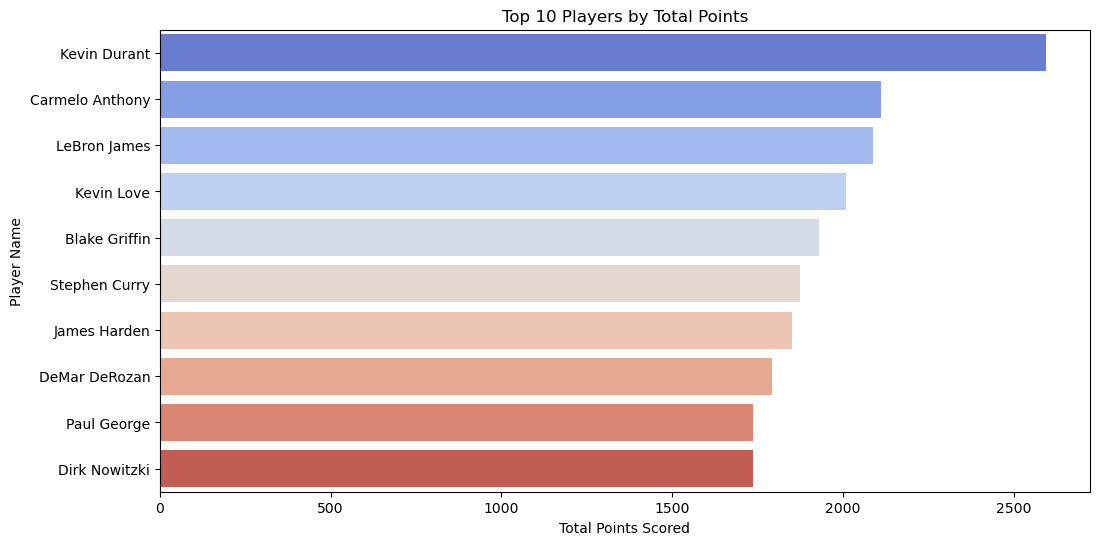

In [492]:

top_players = df.nlargest(10, 'Total_Points_Scored')

plt.figure(figsize=(12, 6))
sns.barplot(x='Total_Points_Scored', y='Player_Name', data=top_players, palette="coolwarm")

plt.xlabel("Total Points Scored")
plt.ylabel("Player Name")
plt.title("Top 10 Players by Total Points")
plt.show()


## Correlation between age and stats like pts, trb, and ast

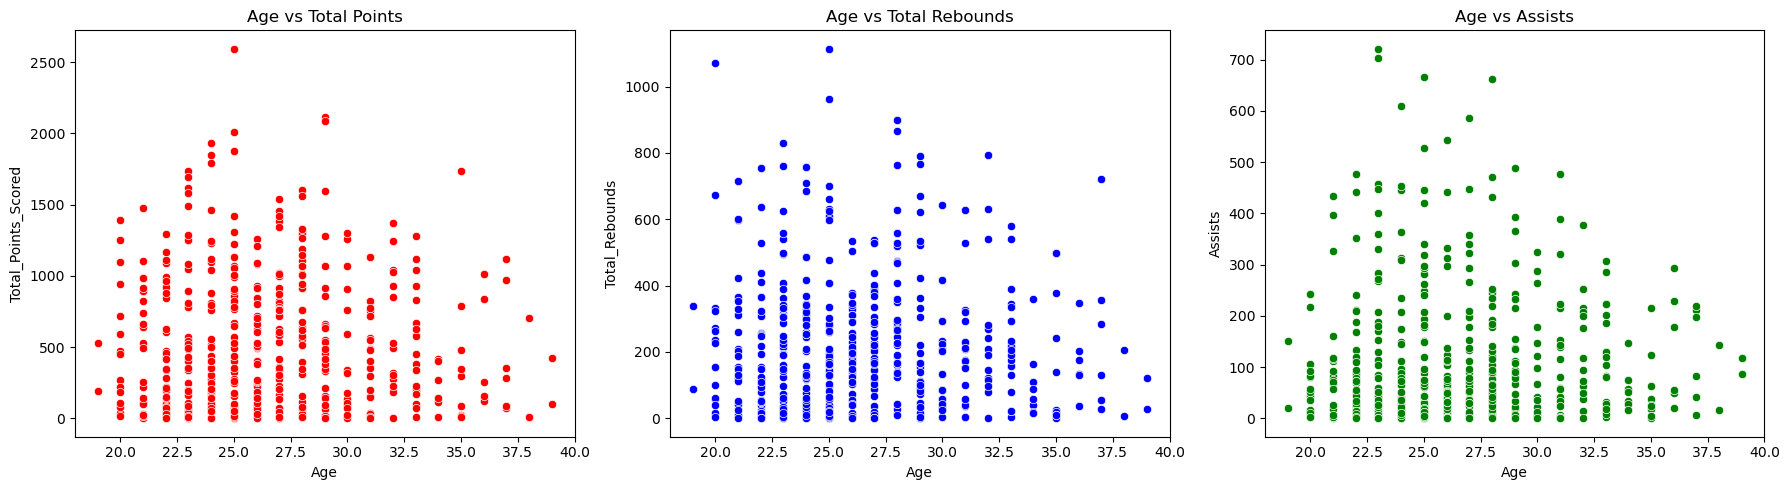

In [495]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=df['Age'], y=df['Total_Points_Scored'], ax=axes[0], color="red")
axes[0].set_title("Age vs Total Points")

sns.scatterplot(x=df['Age'], y=df['Total_Rebounds'], ax=axes[1], color="blue")
axes[1].set_title("Age vs Total Rebounds")

sns.scatterplot(x=df['Age'], y=df['Assists'], ax=axes[2], color="green")
axes[2].set_title("Age vs Assists")

plt.tight_layout()
plt.show()


# Compare team performance in x2p vs. x3p.

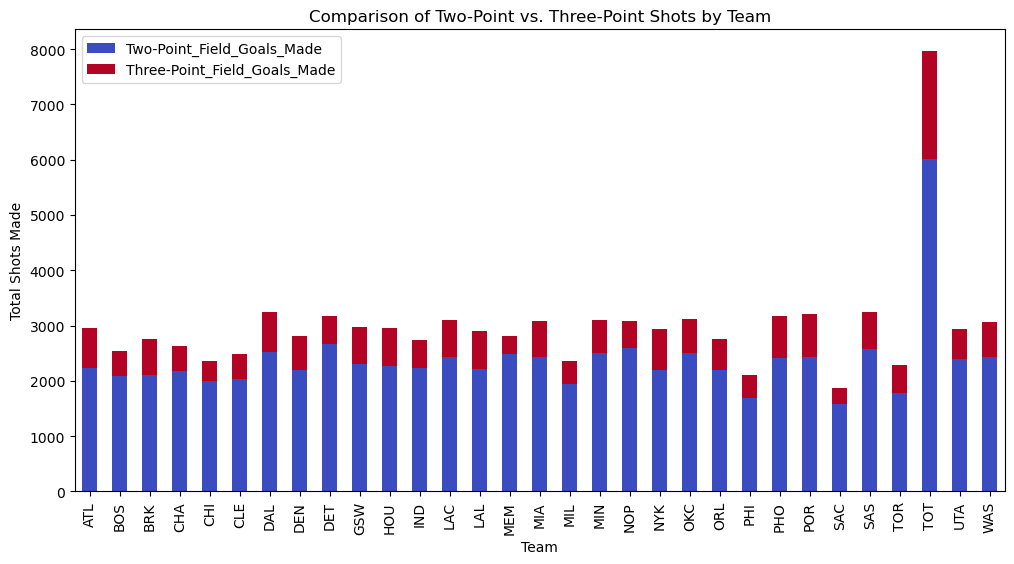

In [500]:
team_shots = df.groupby("Team_Abbreviation")[["Two-Point_Field_Goals_Made", "Three-Point_Field_Goals_Made"]].sum()

team_shots.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="coolwarm")

plt.xlabel("Team")
plt.ylabel("Total Shots Made")
plt.title("Comparison of Two-Point vs. Three-Point Shots by Team")
plt.xticks(rotation=90)
plt.show()


## Age distribution of players across different seasons.

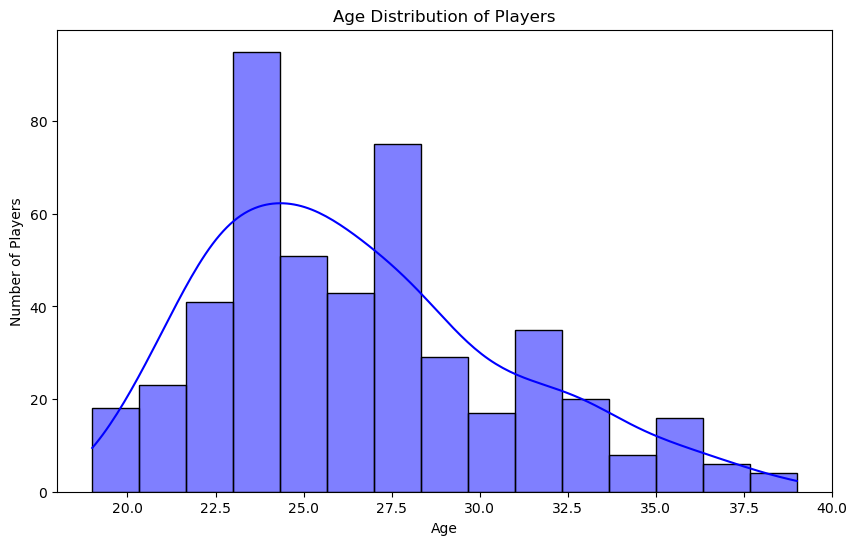

In [507]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=15, kde=True, color='blue')

plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.title("Age Distribution of Players")
plt.show()
